In [80]:
# Import standard libraries, PyTorch modules, and check CUDA device compatibility
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

PyTorch Version: 2.10.0+cu128
CUDA Available: True
Using Device: cuda


### Dataset Overview

The dataset contains distorted visual sequences (CAPTCHAs) used for pattern recognition tasks. It consists of training images and a CSV file (`train-labels.csv`) linking image file names to their corresponding text labels.

In [81]:
# Load the CAPTCHA training labels CSV and display its shape and preview
labels_df = pd.read_csv('/kaggle/input/datasets/hardikgautam24119014/datasetnew/cig_ps/train-labels.csv')

print("Shape:", labels_df.shape)

labels_df.head()

Shape: (20000, 3)


,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


### Data Exploration

Exploratory data analysis is performed to understand label lengths, unique character distribution, missing values, and visual variations of the images. Visualizations and distribution plots reveal consistent sequence lengths and image dimensions of 100x200 pixels.

In [82]:
# Display DataFrame columns, data types, and non-null count information
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  20000 non-null  int64 
 1   image       20000 non-null  object
 2   text        20000 non-null  object
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [83]:
# Generate summary statistics for categorical columns in the dataset
labels_df.describe(include='object')

,image,text
count,20000,20000
unique,20000,19999
top,train-0.png,S9WJPK
freq,1,2


In [84]:
# Check for missing values across all columns
labels_df.isnull().sum()

Unnamed: 0    0
image         0
text          0
dtype: int64

In [85]:
# Preview the full labels DataFrame reference
labels_df.head

<bound method NDFrame.head of        Unnamed: 0            image    text
0               0      train-0.png  BU522X
1               1      train-1.png  XQ8NE2
2               2      train-2.png  DTZD3E
3               3      train-3.png  SM424H
4               4      train-4.png  6YVTQR
...           ...              ...     ...
19995       19995  train-19995.png  ST9ERQ
19996       19996  train-19996.png  CCYT9D
19997       19997  train-19997.png  9X4DMK
19998       19998  train-19998.png  U38HBZ
19999       19999  train-19999.png  ZU5T2N

[20000 rows x 3 columns]>

In [86]:
# Compute label character lengths to verify the expected sequence length
labels_df['label_length'] = labels_df['text'].apply(len)

print("Maximum Length :", labels_df['label_length'].max())
print("Average Length :", labels_df['label_length'].mean())
print("Minimum Length :", labels_df['label_length'].min())

Maximum Length : 9
Average Length : 6.00025
Minimum Length : 6


In [87]:
# Identify and preview labels containing anomalies or length deviation
labels_df[labels_df['label_length'] > 6].head(20)

,Unnamed: 0,image,text,label_length
2184,2184,train-2184.png,5.40E+12,8
6819,6819,train-6819.png,04-Mar-54,9


### Preprocessing

Images are converted to grayscale and normalized to float32 values between 0.0 and 1.0. Corrupted or invalid labels (such as those in scientific notation or date formats) that do not match the expected length of 6 characters are filtered out from the dataset.

In [88]:
# Filter the dataset to include only valid 6-character sequences
labels_df = labels_df[
    labels_df['label_length'] == 6
].copy()

labels_df.reset_index(drop=True, inplace=True)

print(labels_df.shape)

(19998, 4)


In [89]:
# Build vocabulary of unique characters from the filtered CAPTCHA text
all_text = ''.join(labels_df['text'])

vocab = sorted(set(all_text))

print("Vocabulary Size:", len(vocab))
print(vocab)

Vocabulary Size: 31
['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [90]:
# Verify that all remaining labels are exactly 6 characters long
print("Labels longer than 6 chars:",
      len(labels_df[labels_df['label_length'] > 6]))

Labels longer than 6 chars: 0


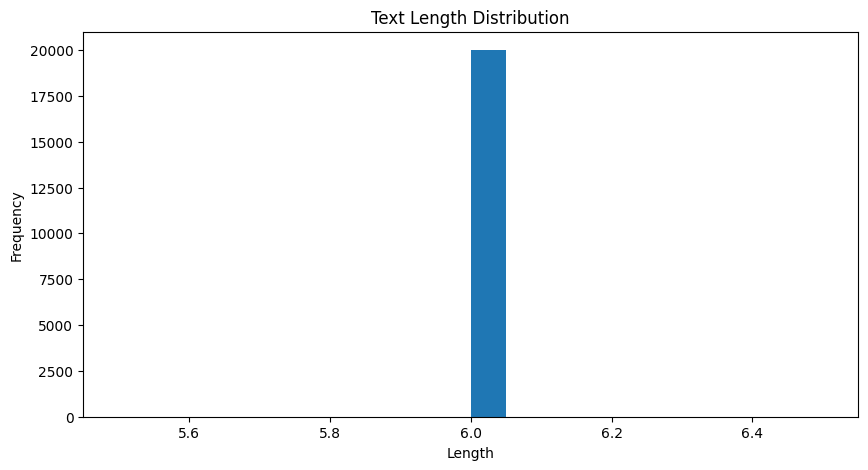

In [91]:
# Plot a histogram to visualize the label character length distribution
plt.figure(figsize=(10,5))
plt.hist(labels_df['label_length'], bins=20)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [92]:
# Set path to the training images directory
IMAGE_FOLDER = "/kaggle/input/datasets/hardikgautam24119014/datasetnew/cig_ps/train_images"

In [93]:
# Read a subset of images to inspect and verify uniform spatial dimensions
sizes = []

for img_name in labels_df['image'].head(1000):

    img_path = os.path.join(
        IMAGE_FOLDER,
        img_name
    )

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    sizes.append(img.shape)

print("Unique sizes:", len(set(sizes)))
print(set(sizes))

Unique sizes: 1
{(100, 200)}


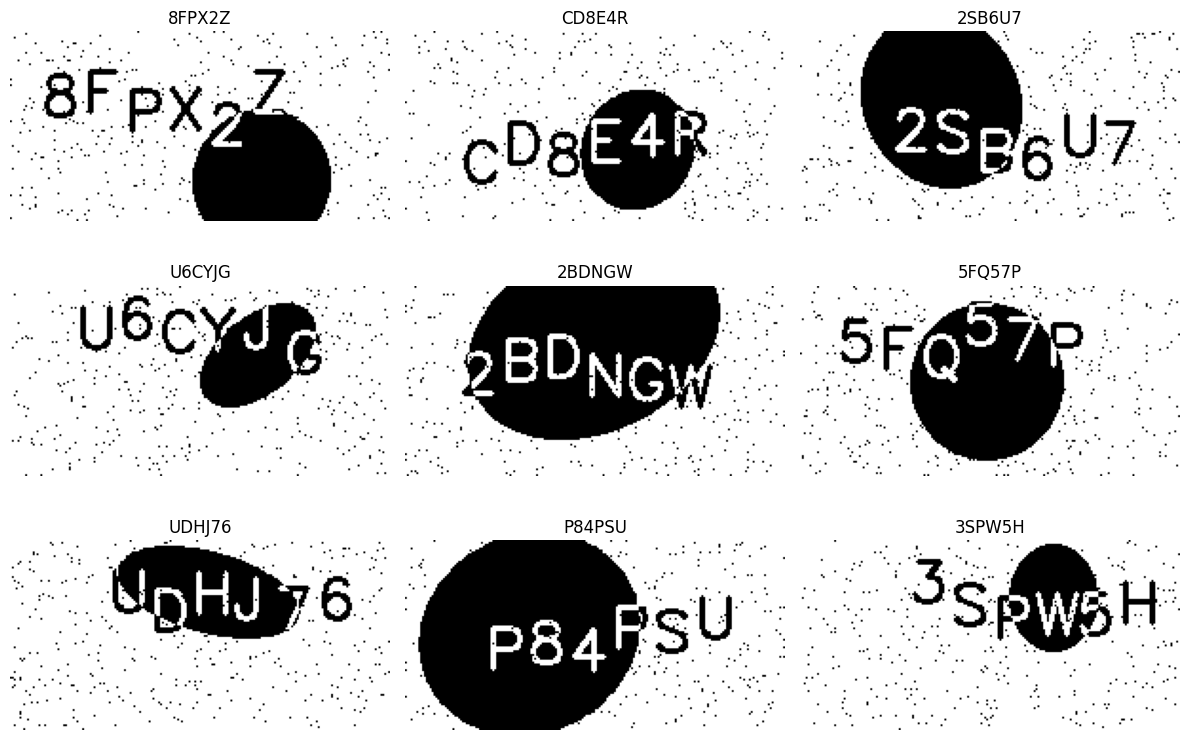

In [94]:
# Visualize random sample images with their associated labels
sample = labels_df.sample(9)

plt.figure(figsize=(12,8))

for i, (_, row) in enumerate(sample.iterrows()):

    img_path = os.path.join(
        IMAGE_FOLDER,
        row['image']
    )

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(row['text'])      # <-- FIXED
    plt.axis('off')

plt.tight_layout()
plt.show()

### Label Encoding

The sequence text labels are converted into numeric representations for model training. A character-to-index vocabulary maps each of the 31 unique alphanumeric characters to a unique integer index, enabling multi-character classification.

In [95]:
# Establish dictionary mappings between characters and integer indices
char_to_idx = {
    char: idx + 1
    for idx, char in enumerate(vocab)
}

idx_to_char = {
    idx + 1: char
    for idx, char in enumerate(vocab)
}

BLANK_IDX = 0

NUM_CLASSES = len(vocab) + 1

print("Vocabulary Size:", len(vocab))
print("Number of Classes:", NUM_CLASSES)

Vocabulary Size: 31
Number of Classes: 32


In [96]:
# Partition the dataset into stratified training (90%) and validation (10%) splits
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    labels_df,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (17998, 4)
Validation: (2000, 4)


### Dataset & DataLoader Creation

A custom PyTorch `Dataset` is defined to handle image reading, normalization, tensor conversion, and label encoding. `DataLoader` instances are then created for both training and validation splits with a batch size of 128 to facilitate mini-batch gradient descent.

In [97]:
# Create a PyTorch Dataset for loading grayscale images and mapping alphanumeric labels
class CaptchaDataset(Dataset):

    def __init__(self, dataframe, image_folder):

        self.df = dataframe.reset_index(drop=True)
        self.image_folder = image_folder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(
            self.image_folder,
            row['image']
        )

        image = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = image.astype(np.float32) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        label = torch.tensor(
            [char_to_idx[ch] - 1 for ch in row['text']],
            dtype=torch.long
        )

        return image, label

In [98]:
# Instantiate CaptchaDataset for train and validation splits
train_dataset = CaptchaDataset(
    train_df,
    IMAGE_FOLDER
)

val_dataset = CaptchaDataset(
    val_df,
    IMAGE_FOLDER
)

print(len(train_dataset))
print(len(val_dataset))

17998
2000


In [99]:
# Retrieve and inspect a single dataset item to verify tensor shapes
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Encoded Label:", label)

Image Shape: torch.Size([1, 100, 200])
Encoded Label: tensor([ 6, 26, 23, 19,  6,  9])


In [100]:
# Create DataLoader instances for batching, shuffling, and pinned memory access
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [101]:
# Fetch and inspect a batch of images and labels from the DataLoader
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 1, 100, 200])
torch.Size([128, 6])


### Model Architecture

The pattern recognition model utilizes a modified ResNet-18 backbone. The first convolutional layer is adapted to accept 1-channel grayscale input, and the spatial dimensions are pooled using `AdaptiveAvgPool2d` to extract features corresponding to 6 sequence character slots for classification.

In [102]:
# Define ResNet-18 model modified for single-channel input and 6 character slot classification
class ResNetCaptcha(nn.Module):

    def __init__(self, num_chars):

        super().__init__()

        backbone = models.resnet18(weights="DEFAULT")

        backbone.conv1 = nn.Conv2d(
            1,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,

            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 6))

        self.classifier = nn.Linear(
            512,
            num_chars
        )

        self.num_chars = num_chars

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = x.squeeze(2)

        x = x.permute(0, 2, 1)

        x = self.classifier(x)

        return x

In [103]:
# Instantiate ResNetCaptcha model and move to active device
NUM_CHARS = len(vocab)

model = ResNetCaptcha(
    NUM_CHARS
).to(device)

print(model)

ResNetCaptcha(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

### Training Strategy

The model is trained using the AdamW optimizer with a learning rate of 3e-4 and weight decay of 1e-4. The loss function is CrossEntropyLoss with 0.1 label smoothing, and a ReduceLROnPlateau scheduler dynamically decreases the learning rate on validation loss plateau.

In [128]:
# Initialize multi-label classification loss with label smoothing
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [105]:
# Initialize AdamW optimizer with weight decay
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [106]:
# Set up ReduceLROnPlateau learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

### Evaluation Metrics

Performance is monitored using character-level accuracy, sequence-level accuracy (requiring all characters to match), and Character Error Rate (CER). CER measures the distance between the predicted text and ground truth using insertion, deletion, and substitution edits.

In [107]:
# Helper function to calculate average character-level classification accuracy
def character_accuracy(outputs, labels):

    preds = outputs.argmax(dim=2)

    correct = (preds == labels).sum().item()

    total = labels.numel()

    return 100 * correct / total

In [108]:
# Helper function to compute exact sequence-level match accuracy
def calculate_accuracy(outputs, labels):

    preds = outputs.argmax(dim=2)

    correct = (preds == labels).all(dim=1)

    return correct.float().mean().item() * 100

In [109]:
# Helper function to prepare target labels for classification
def prepare_targets(labels):

    target_lengths = torch.full(
        size=(labels.size(0),),
        fill_value=labels.size(1),
        dtype=torch.long
    )

    targets = labels.view(-1)

    return targets, target_lengths

In [110]:
# Decode integer prediction indices back into characters
def decode_prediction(pred):

    text = ""

    for idx in pred:
        text += vocab[idx]

    return text

In [111]:
# Utility function to print ground truth versus model predictions for sample validation images
def show_predictions(model, loader, n=5):

    model.eval()

    with torch.no_grad():

        images, labels = next(iter(loader))

        outputs = model(
            images.to(device)
        )

        preds = outputs.argmax(dim=2)

        for i in range(n):

            gt = decode_prediction(
                labels[i].numpy()
            )

            pr = decode_prediction(
                preds[i].cpu().numpy()
            )

            print(f"GT   : {gt}")
            print(f"PRED : {pr}")
            print("-"*50)

In [112]:
# Decode batch of integer labels to text sequences
def decode_labels(labels):

    texts = []

    for label in labels:

        text = ""

        for idx in label.cpu().numpy():

            text += idx_to_char.get(idx, "")

        texts.append(text)

    return texts

In [113]:
# Run validation evaluation loop, computing loss, sequence match accuracy, and character accuracy
def validate(model, loader):

    model.eval()

    total_loss = 0
    total_seq_acc = 0
    total_char_acc = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = 0

            for i in range(6):

                loss += criterion(
                    outputs[:, i, :],
                    labels[:, i]
                )

            total_loss += loss.item()

            seq_acc = calculate_accuracy(
                outputs,
                labels
            )

            char_acc = character_accuracy(
                outputs,
                labels
            )

            total_seq_acc += seq_acc
            total_char_acc += char_acc

    avg_loss = total_loss / len(loader)
    avg_seq_acc = total_seq_acc / len(loader)
    avg_char_acc = total_char_acc / len(loader)

    return avg_loss, avg_seq_acc, avg_char_acc

In [129]:
# Train the model for 40 epochs, tracking validation metrics and saving the best checkpoint
from tqdm.auto import tqdm
import time
import torch

EPOCHS = 40

best_char_acc = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    start_time = time.time()

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = 0

        for i in range(6):

            loss += criterion(
                outputs[:, i, :],
                labels[:, i]
            )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += loss.item()

        pbar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "LR": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    val_loss, val_acc, char_acc = validate(
    model,
    val_loader
        )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - start_time

    print("\n" + "=" * 70)
    print(f"Epoch         : {epoch+1}/{EPOCHS}")
    print(f"Train Loss    : {running_loss / len(train_loader):.4f}")
    print(f"Val Accuracy  : {val_acc:.2f}%")
    print(f"Char Accuracy : {char_acc:.2f}%")
    print(f"Learning Rate : {current_lr:.6f}")
    print(f"Time          : {epoch_time:.2f}s")
    print("=" * 70)

    show_predictions(
        model,
        val_loader,
        5
    )

    if char_acc > best_char_acc:

        best_char_acc = char_acc

        torch.save(
            model.state_dict(),
            "best_resnet_captcha.pth"
        )

        print("\n✅ New Best Model Saved")
        print(f"✅ Best Char Accuracy : {best_char_acc:.2f}%")

Epoch 1/40:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch         : 1/40
Train Loss    : 4.8876
Val Accuracy  : 99.14%
Char Accuracy : 99.83%
Learning Rate : 0.000300
Time          : 72.95s
GT   : TDJ3F4
PRED : TDJ3F4
--------------------------------------------------
GT   : SEKSCT
PRED : SEKSCT
--------------------------------------------------
GT   : 9EQ4U4
PRED : 9EQ4U4
--------------------------------------------------
GT   : U3RBDY
PRED : U3RBDY
--------------------------------------------------
GT   : MNYSDG
PRED : MNY5DG
--------------------------------------------------

✅ New Best Model Saved
✅ Best Char Accuracy : 99.83%


Epoch 2/40:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch         : 2/40
Train Loss    : 4.1404
Val Accuracy  : 99.48%
Char Accuracy : 99.90%
Learning Rate : 0.000300
Time          : 56.08s
GT   : TDJ3F4
PRED : TDJ3F4
--------------------------------------------------
GT   : SEKSCT
PRED : SEKSCT
--------------------------------------------------
GT   : 9EQ4U4
PRED : 9EQ4U4
--------------------------------------------------
GT   : U3RBDY
PRED : U3RBDY
--------------------------------------------------
GT   : MNYSDG
PRED : MNYSDG
--------------------------------------------------

✅ New Best Model Saved
✅ Best Char Accuracy : 99.90%


Epoch 3/40:   0%|          | 0/141 [00:00<?, ?it/s]

...


Epoch         : 38/40
Train Loss    : 3.9341
Val Accuracy  : 99.76%
Char Accuracy : 99.94%
Learning Rate : 0.000000
Time          : 58.70s
GT   : TDJ3F4
PRED : TDJ3F4
--------------------------------------------------
GT   : SEKSCT
PRED : SEKSCT
--------------------------------------------------
GT   : 9EQ4U4
PRED : 9EQ4U4
--------------------------------------------------
GT   : U3RBDY
PRED : U3RBDY
--------------------------------------------------
GT   : MNYSDG
PRED : MNYSDG
--------------------------------------------------


Epoch 39/40:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch         : 39/40
Train Loss    : 3.9342
Val Accuracy  : 99.71%
Char Accuracy : 99.93%
Learning Rate : 0.000000
Time          : 61.41s
GT   : TDJ3F4
PRED : TDJ3F4
--------------------------------------------------
GT   : SEKSCT
PRED : SEKSCT
--------------------------------------------------
GT   : 9EQ4U4
PRED : 9EQ4U4
--------------------------------------------------
GT   : U3RBDY
PRED : U3RBDY
--------------------------------------------------
GT   : MNYSDG
PRED : MNYSDG
--------------------------------------------------


Epoch 40/40:   0%|          | 0/141 [00:00<?, ?it/s]


Epoch         : 40/40
Train Loss    : 3.9342
Val Accuracy  : 99.76%
Char Accuracy : 99.94%
Learning Rate : 0.000000
Time          : 60.17s
GT   : TDJ3F4
PRED : TDJ3F4
--------------------------------------------------
GT   : SEKSCT
PRED : SEKSCT
--------------------------------------------------
GT   : 9EQ4U4
PRED : 9EQ4U4
--------------------------------------------------
GT   : U3RBDY
PRED : U3RBDY
--------------------------------------------------
GT   : MNYSDG
PRED : MNYSDG
--------------------------------------------------


In [117]:
# Install jiwer library for computing Character Error Rate (CER)
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.9 MB/s eta 0:00:0000:0100:01


### Results

After training for 40 epochs, the best model checkpoint is loaded and evaluated on the validation set. The model achieves high character accuracy (99.94%), sequence accuracy (99.70%), and a low Character Error Rate (CER) of 0.0006.

In [130]:
# Load the best validation checkpoint and calculate final accuracy and CER metrics
from jiwer import cer

# Load Best Model
model.load_state_dict(
    torch.load(
        "best_resnet_captcha.pth",
        map_location=device
    )
)

model.eval()

total_cer = 0
total_chars = 0
total_seq_correct = 0
total_char_correct = 0
total_samples = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=2).cpu()

        total_char_correct += (preds == labels).sum().item()

        total_chars += labels.numel()

        total_seq_correct += (
            (preds == labels).all(dim=1)
        ).sum().item()

        total_samples += labels.size(0)

        for i in range(labels.size(0)):

            gt = decode_prediction(
                labels[i].numpy()
            )

            pred = decode_prediction(
                preds[i].numpy()
            )

            total_cer += cer(gt, pred)

final_cer = total_cer / total_samples

char_acc = 100 * total_char_correct / total_chars

seq_acc = 100 * total_seq_correct / total_samples

print("=" * 60)
print(f"Character Accuracy : {char_acc:.2f}%")
print(f"Sequence Accuracy  : {seq_acc:.2f}%")
print(f"CER                : {final_cer:.4f}")
print(f"CER (%)            : {final_cer*100:.2f}%")
print("=" * 60)

Character Accuracy : 99.94%
Sequence Accuracy  : 99.70%
CER                : 0.0006
CER (%)            : 0.06%


### Error Analysis

Incorrectly predicted validation samples are extracted and analyzed to identify common failure modes. Reviewing these rare errors helps diagnose whether distortions like overlapping characters or high noise led to misclassifications.

In [131]:
# Scan validation set and compile list of misclassified instances for error analysis
wrong_samples = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=2).cpu()

        for i in range(labels.size(0)):

            gt = decode_prediction(
                labels[i].numpy()
            )

            pred = decode_prediction(
                preds[i].numpy()
            )

            if gt != pred:

                wrong_samples.append(
                    (images[i].cpu(), gt, pred)
                )

print("Wrong Samples:", len(wrong_samples))

Wrong Samples: 6


### Test Prediction Generation

Test predictions are generated on unseen images using the trained ResNet-18 model. The inference pipeline loads the best model checkpoint, runs predictions in evaluation mode, and outputs the results to a submission CSV file as shown in `02_predict.ipynb`.

In [132]:
# Save the final trained model weights
torch.save(
    model.state_dict(),
    "final_resnet18_captcha.pth"
)

### Reproducibility

To ensure reproducibility, model weights, optimizer state, and training metrics are saved to serialized PyTorch checkpoints. This allows the complete training state to be restored and evaluated consistently across environments.

In [137]:
# Save checkpoint containing model weights, optimizer state, and final metrics
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "char_acc": 99.94,
    "seq_acc": 99.70,
    "cer": 0.0006,
    "wrong_samples": 6
}, "captcha_checkpoint.pth")